# Phase 3: Model Improvement — Ablation, Tuning & Extension Method
**Project:** Test-Time Adaptation using TENT on CIFAR-10-C  
**Timeline:** Apr 20 – Apr 24  

---
### Objectives
1. Ablation studies to understand each TENT component
2. Hyperparameter tuning (learning rate, batch size)
3. Propose and implement a new extension method: **MATTA**
   - Multi-View Augmentation + EMA Teacher Test-Time Adaptation

### Extension Method: MATTA
MATTA improves over vanilla TENT by:
- **EMA Teacher**: stabilizes adaptation with an exponential moving average copy of the student
- **Multi-View Consistency**: uses augmented views for more robust entropy estimation
- **Structural Augmentations**: deterministic transforms (flip, roll, contrast) instead of noisy perturbations

## 3.1 Setup

In [8]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'robustbench', 'timm', 'einops', '-q'], check=False)

import types
mock_aa = types.ModuleType('autoattack')
mock_aa_state = types.ModuleType('autoattack.state')
mock_aa_state.EvaluationState = type('EvaluationState', (), {})
mock_aa.state = mock_aa_state
mock_aa.AutoAttack = type('AutoAttack', (), {'__init__': lambda *a, **kw: None})
sys.modules['autoattack'] = mock_aa
sys.modules['autoattack.state'] = mock_aa_state

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

from torch.utils.data import DataLoader, TensorDataset
from robustbench.data import load_cifar10c
from robustbench.utils import load_model

torch.manual_seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

CORRUPTIONS = [
    'gaussian_noise', 'shot_noise', 'impulse_noise',
    'defocus_blur', 'glass_blur', 'motion_blur', 'zoom_blur',
    'snow', 'frost', 'fog', 'brightness',
    'contrast', 'elastic_transform', 'pixelate', 'jpeg_compression'
]
N_EXAMPLES = 1000
BATCH_SIZE = 64
SEVERITY = 5
DATA_DIR = './data'

print('Loading WideResNet-28-10...')
source_model = load_model(model_name='Standard', dataset='cifar10', threat_model='corruptions').to(DEVICE).eval()
print('Model loaded.')

Device: cuda
Loading WideResNet-28-10...
Model loaded.


## 3.2 Baseline TENT (for comparison)

In [10]:
def configure_all_bn(model):
    model.eval()
    model.requires_grad_(False)
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.requires_grad_(True)
            m.track_running_stats = False
            m.running_mean = None
            m.running_var = None
    return model


def run_tent_baseline(base_model, corruptions, n_examples, batch_size, severity, data_dir, device, lr=1e-3):
    """Episodic TENT — reference baseline for Phase 3."""
    results = []
    for corr in corruptions:
        x, y = load_cifar10c(n_examples=n_examples, corruptions=[corr],
                             severity=severity, data_dir=data_dir)
        loader = DataLoader(TensorDataset(x, y), batch_size=batch_size, shuffle=False)
        model = configure_all_bn(copy.deepcopy(base_model))
        opt = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
        correct = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            with torch.enable_grad():
                out = model(xb)
                loss = -(out.softmax(1) * out.log_softmax(1)).sum(1).mean()
                loss.backward()
                opt.step()
                opt.zero_grad()
            correct += (out.argmax(1) == yb).sum().item()
        results.append({'Corruption': corr, 'Baseline_TENT %': round(100*(1-correct/n_examples), 2)})
    df = pd.DataFrame(results)
    print(f'Baseline TENT mean error: {df["Baseline_TENT %"].mean():.2f}%')
    return df


print('Running TENT baseline...')
df_baseline = run_tent_baseline(source_model, CORRUPTIONS, N_EXAMPLES, BATCH_SIZE, SEVERITY, DATA_DIR, DEVICE)

Running TENT baseline...
Baseline TENT mean error: 20.25%


## 3.3 Ablation Study — BN Layer Selection

In [12]:
def configure_deep_layers_only(model):
    """Ablation: adapt only BN layers in deep blocks (last 50% of BN layers)."""
    model.eval()
    model.requires_grad_(False)
    
    # Collect all BN layer names
    bn_layers = []
    for name, m in model.named_modules():
        if isinstance(m, nn.BatchNorm2d):
            bn_layers.append((name, m))
    
    # Adapt only deeper half of BN layers
    n_deep = len(bn_layers) // 2
    for name, m in bn_layers[-n_deep:]:  # Last n_deep layers
        m.requires_grad_(True)
        m.track_running_stats = False
        m.running_mean = None
        m.running_var = None
    
    print(f"  Configured {n_deep}/{len(bn_layers)} deep BN layers for adaptation")
    return model


def configure_shallow_layers_only(model):
    """Ablation: adapt only BN layers in shallow blocks (first 50% of BN layers)."""
    model.eval()
    model.requires_grad_(False)
    
    # Collect all BN layer names
    bn_layers = []
    for name, m in model.named_modules():
        if isinstance(m, nn.BatchNorm2d):
            bn_layers.append((name, m))
    
    # Adapt only shallow half of BN layers
    n_shallow = len(bn_layers) // 2
    for name, m in bn_layers[:n_shallow]:  # First n_shallow layers
        m.requires_grad_(True)
        m.track_running_stats = False
        m.running_mean = None
        m.running_var = None
    
    print(f"  Configured {n_shallow}/{len(bn_layers)} shallow BN layers for adaptation")
    return model


def run_tent_with_configure(base_model, configure_fn, label, corruptions,
                            n_examples, batch_size, severity, data_dir, device, lr=1e-3):
    results = []
    for corr in corruptions:
        print(f"  Processing {corr}...")
        x, y = load_cifar10c(n_examples=n_examples, corruptions=[corr],
                             severity=severity, data_dir=data_dir)
        loader = DataLoader(TensorDataset(x, y), batch_size=batch_size, shuffle=False)
        model = configure_fn(copy.deepcopy(base_model))
        
        # Check if there are any trainable parameters
        trainable_params = [p for p in model.parameters() if p.requires_grad]
        if len(trainable_params) == 0:
            print(f"    WARNING: No trainable parameters for {label} on {corr}")
            results.append({'Corruption': corr, f'{label} %': 100.0})
            continue
            
        opt = optim.Adam(trainable_params, lr=lr)
        correct = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            with torch.enable_grad():
                out = model(xb)
                loss = -(out.softmax(1) * out.log_softmax(1)).sum(1).mean()
                loss.backward()
                opt.step()
                opt.zero_grad()
            correct += (out.argmax(1) == yb).sum().item()
        error = 100 * (1 - correct / n_examples)
        results.append({'Corruption': corr, f'{label} %': round(error, 2)})
        print(f"    Error: {error:.2f}%")
    df = pd.DataFrame(results)
    print(f'{label} mean error: {df[f"{label} %"].mean():.2f}%')
    return df


print('Ablation A: Deep layers only...')
df_abl_deep = run_tent_with_configure(source_model, configure_deep_layers_only, 'Abl_DeepOnly',
                                       CORRUPTIONS, N_EXAMPLES, BATCH_SIZE, SEVERITY, DATA_DIR, DEVICE)

print('\nAblation B: Shallow layers only...')
df_abl_shallow = run_tent_with_configure(source_model, configure_shallow_layers_only, 'Abl_ShallowOnly',
                                          CORRUPTIONS, N_EXAMPLES, BATCH_SIZE, SEVERITY, DATA_DIR, DEVICE)

Ablation A: Deep layers only...
  Processing gaussian_noise...
  Configured 12/25 deep BN layers for adaptation
    Error: 39.40%
  Processing shot_noise...
  Configured 12/25 deep BN layers for adaptation
    Error: 35.90%
  Processing impulse_noise...
  Configured 12/25 deep BN layers for adaptation
    Error: 53.90%
  Processing defocus_blur...
  Configured 12/25 deep BN layers for adaptation
    Error: 18.30%
  Processing glass_blur...
  Configured 12/25 deep BN layers for adaptation
    Error: 36.20%
  Processing motion_blur...
  Configured 12/25 deep BN layers for adaptation
    Error: 15.40%
  Processing zoom_blur...
  Configured 12/25 deep BN layers for adaptation
    Error: 17.30%
  Processing snow...
  Configured 12/25 deep BN layers for adaptation
    Error: 19.30%
  Processing frost...
  Configured 12/25 deep BN layers for adaptation
    Error: 21.20%
  Processing fog...
  Configured 12/25 deep BN layers for adaptation
    Error: 16.50%
  Processing brightness...
  Configur

## 3.4 Hyperparameter Tuning — Learning Rate Search

In [13]:
# Use a representative subset of corruptions for the tuning sweep
TUNING_CORRUPTIONS = ['gaussian_noise', 'defocus_blur', 'snow', 'contrast', 'jpeg_compression']
LR_CANDIDATES = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]

print('Hyperparameter tuning: learning rate search')
lr_tuning_results = []

for lr in LR_CANDIDATES:
    errs = []
    for corr in TUNING_CORRUPTIONS:
        x, y = load_cifar10c(n_examples=N_EXAMPLES, corruptions=[corr],
                             severity=SEVERITY, data_dir=DATA_DIR)
        loader = DataLoader(TensorDataset(x, y), batch_size=BATCH_SIZE, shuffle=False)
        model = configure_all_bn(copy.deepcopy(source_model))
        opt = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
        correct = 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            with torch.enable_grad():
                out = model(xb)
                loss = -(out.softmax(1) * out.log_softmax(1)).sum(1).mean()
                loss.backward()
                opt.step()
                opt.zero_grad()
            correct += (out.argmax(1) == yb).sum().item()
        errs.append(100*(1-correct/N_EXAMPLES))
    mean_err = np.mean(errs)
    lr_tuning_results.append({'LR': lr, 'Mean Error %': round(mean_err, 2)})
    print(f'  lr={lr:.0e}  Mean Error: {mean_err:.2f}%')

df_lr = pd.DataFrame(lr_tuning_results)
best_lr = df_lr.loc[df_lr['Mean Error %'].idxmin(), 'LR']
print(f'\nBest LR: {best_lr}')

Hyperparameter tuning: learning rate search
  lr=1e-04  Mean Error: 19.82%
  lr=5e-04  Mean Error: 19.68%
  lr=1e-03  Mean Error: 19.50%
  lr=5e-03  Mean Error: 20.50%
  lr=1e-02  Mean Error: 25.72%

Best LR: 0.001


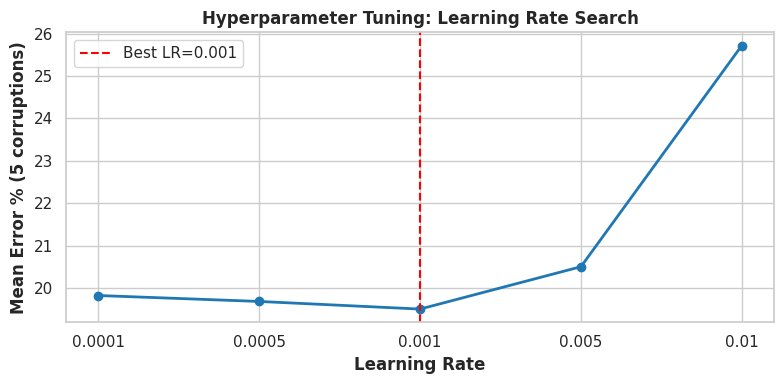

Saved: phase3_lr_tuning.png


In [14]:
plt.figure(figsize=(8, 4))
plt.plot(df_lr['LR'].astype(str), df_lr['Mean Error %'], marker='o', color='#1f78b4', linewidth=2)
plt.axvline(x=df_lr['LR'].astype(str)[df_lr['Mean Error %'].idxmin()], color='red', linestyle='--', label=f'Best LR={best_lr}')
plt.ylabel('Mean Error % (5 corruptions)', fontweight='bold')
plt.xlabel('Learning Rate', fontweight='bold')
plt.title('Hyperparameter Tuning: Learning Rate Search', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('phase3_lr_tuning.png', dpi=150)
plt.show()
print('Saved: phase3_lr_tuning.png')

## 3.5 Extension Method: MATTA

**MATTA** (Multi-view Augmentation with Teacher Test-Time Adaptation):
1. Maintains an **EMA Teacher** as a stable prediction reference
2. Generates **multiple structural augmented views** per batch
3. Minimizes **KL divergence** between student and teacher predictions on augmented views
4. Updates **teacher via EMA** after each step

In [15]:
class MATTAModel(nn.Module):
    """
    MATTA: Multi-View Augmentation + EMA Teacher Test-Time Adaptation.
    Student adapts BN layers; teacher provides stable soft targets.
    """
    def __init__(self, student, lr=1e-3, alpha=0.99, num_views=4):
        super().__init__()
        self.student = self._configure_student(student)
        self.teacher = copy.deepcopy(student)  # teacher: frozen, updated only via EMA
        self.teacher.eval()
        self.teacher.requires_grad_(False)
        self.optimizer = optim.Adam([p for p in self.student.parameters() if p.requires_grad], lr=lr)
        self.alpha = alpha
        self.num_views = num_views

    @staticmethod
    def _configure_student(model):
        model.eval()
        model.requires_grad_(False)
        for m in model.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.requires_grad_(True)
                m.track_running_stats = False
                m.running_mean = None
                m.running_var = None
        return model

    @torch.no_grad()
    def _ema_update(self):
        """Update teacher via exponential moving average of student weights."""
        for s_p, t_p in zip(self.student.parameters(), self.teacher.parameters()):
            t_p.data = self.alpha * t_p.data + (1 - self.alpha) * s_p.data

    @staticmethod
    def _augment(x, view_idx):
        """Deterministic structural augmentations for multi-view consistency."""
        if view_idx == 0:
            return torch.flip(x, dims=[3])               # horizontal flip
        elif view_idx == 1:
            return torch.roll(x, shifts=(2, 2), dims=(2, 3))  # translate
        elif view_idx == 2:
            return torch.roll(x, shifts=(-2, -2), dims=(2, 3))
        else:
            return x * 0.95 + 0.025                     # brightness scale

    def forward(self, x):
        """
        MATTA forward pass:
        1. For each augmented view, compute student prediction
        2. Get soft target from teacher on same view (no grad)
        3. Minimize KL(student || teacher) across views
        4. Update student; then EMA-update teacher
        5. Return primary (non-augmented) student prediction
        """
        losses = []
        for v in range(self.num_views):
            xv = self._augment(x, v)
            student_out = self.student(xv)
            with torch.no_grad():
                teacher_out = self.teacher(xv)
            # KL divergence: student distribution vs teacher distribution
            kl = F.kl_div(
                student_out.log_softmax(dim=1),
                teacher_out.softmax(dim=1),
                reduction='batchmean'
            )
            losses.append(kl)

        total_loss = torch.stack(losses).mean()
        total_loss.backward()
        self.optimizer.step()
        self.optimizer.zero_grad()
        self._ema_update()

        # Primary prediction from student
        with torch.no_grad():
            primary_out = self.student(x)
        return primary_out


print('MATTA class defined.')

MATTA class defined.


## 3.6 MATTA Ablation — Component Analysis

In [16]:
def run_matta(base_model, corruptions, n_examples, batch_size, severity, data_dir, device,
              lr=1e-3, alpha=0.99, num_views=4, label='MATTA'):
    results = []
    for corr in corruptions:
        x, y = load_cifar10c(n_examples=n_examples, corruptions=[corr],
                             severity=severity, data_dir=data_dir)
        loader = DataLoader(TensorDataset(x, y), batch_size=batch_size, shuffle=False)
        matta = MATTAModel(copy.deepcopy(base_model), lr=lr, alpha=alpha, num_views=num_views).to(device)
        correct = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            with torch.enable_grad():
                out = matta(xb)
            correct += (out.argmax(1) == yb).sum().item()
        results.append({'Corruption': corr, f'{label} %': round(100*(1-correct/n_examples), 2)})
        print(f'  {corr:<25} {100*(1-correct/n_examples):.2f}%')
    df = pd.DataFrame(results)
    print(f'{label} mean error: {df[f"{label} %"].mean():.2f}%')
    return df


print('Running Full MATTA (EMA + 4 augmented views)...')
df_matta = run_matta(source_model, CORRUPTIONS, N_EXAMPLES, BATCH_SIZE, SEVERITY, DATA_DIR, DEVICE,
                     lr=best_lr, alpha=0.99, num_views=4, label='MATTA_Full')

Running Full MATTA (EMA + 4 augmented views)...
  gaussian_noise            28.00%
  shot_noise                26.00%
  impulse_noise             37.40%
  defocus_blur              12.60%
  glass_blur                34.10%
  motion_blur               12.40%
  zoom_blur                 13.00%
  snow                      17.40%
  frost                     19.20%
  fog                       15.50%
  brightness                7.80%
  contrast                  14.00%
  elastic_transform         23.60%
  pixelate                  19.90%
  jpeg_compression          27.20%
MATTA_Full mean error: 20.54%


In [17]:
# Ablation: no EMA (alpha=0 means teacher is never updated)
print('Ablation: No EMA (static teacher)...')
df_matta_no_ema = run_matta(source_model, CORRUPTIONS, N_EXAMPLES, BATCH_SIZE, SEVERITY, DATA_DIR, DEVICE,
                             lr=best_lr, alpha=0.0, num_views=4, label='Abl_NoEMA')

Ablation: No EMA (static teacher)...
  gaussian_noise            27.90%
  shot_noise                26.50%
  impulse_noise             38.10%
  defocus_blur              12.80%
  glass_blur                33.90%
  motion_blur               12.70%
  zoom_blur                 13.10%
  snow                      17.50%
  frost                     18.90%
  fog                       15.40%
  brightness                8.00%
  contrast                  13.90%
  elastic_transform         23.80%
  pixelate                  19.80%
  jpeg_compression          27.10%
Abl_NoEMA mean error: 20.63%


In [18]:
# Ablation: no multi-view (1 view = no augmentation)
print('Ablation: No Multi-View (1 view only)...')
df_matta_no_aug = run_matta(source_model, CORRUPTIONS, N_EXAMPLES, BATCH_SIZE, SEVERITY, DATA_DIR, DEVICE,
                             lr=best_lr, alpha=0.99, num_views=1, label='Abl_NoAug')

Ablation: No Multi-View (1 view only)...
  gaussian_noise            28.00%
  shot_noise                26.90%
  impulse_noise             37.80%
  defocus_blur              12.70%
  glass_blur                33.90%
  motion_blur               12.70%
  zoom_blur                 13.10%
  snow                      17.00%
  frost                     18.60%
  fog                       15.20%
  brightness                7.90%
  contrast                  14.20%
  elastic_transform         24.20%
  pixelate                  19.40%
  jpeg_compression          27.60%
Abl_NoAug mean error: 20.61%


## 3.7 Phase 3 Results Table

In [19]:
df_p3 = df_baseline.copy()
df_p3 = df_p3.merge(df_abl_deep, on='Corruption')
df_p3 = df_p3.merge(df_abl_shallow, on='Corruption')
df_p3 = df_p3.merge(df_matta_no_ema, on='Corruption')
df_p3 = df_p3.merge(df_matta_no_aug, on='Corruption')
df_p3 = df_p3.merge(df_matta, on='Corruption')

print('='*100)
print('                  PHASE 3: ABLATION STUDY & MATTA RESULTS')
print('='*100)
print(df_p3.to_string(index=False))
print('-'*100)
for col in df_p3.columns[1:]:
    mean_err = df_p3[col].mean()
    mean_acc = 100 - mean_err
    print(f'  {col:<25}  Error: {mean_err:.2f}%   Acc: {mean_acc:.2f}%')
print('='*100)

df_p3.to_csv('phase3_results.csv', index=False)
print('Saved: phase3_results.csv')

                  PHASE 3: ABLATION STUDY & MATTA RESULTS
       Corruption  Baseline_TENT %  Abl_DeepOnly %  Abl_ShallowOnly %  Abl_NoEMA %  Abl_NoAug %  MATTA_Full %
   gaussian_noise             26.7            39.4               29.1         27.9         28.0          28.0
       shot_noise             25.5            35.9               27.9         26.5         26.9          26.0
    impulse_noise             37.1            53.9               43.5         38.1         37.8          37.4
     defocus_blur             12.2            18.3               11.8         12.8         12.7          12.6
       glass_blur             33.3            36.2               39.7         33.9         33.9          34.1
      motion_blur             13.3            15.4               12.5         12.7         12.7          12.4
        zoom_blur             12.6            17.3               11.6         13.1         13.1          13.0
             snow             17.3            19.3            

## 3.8 Ablation Visualization

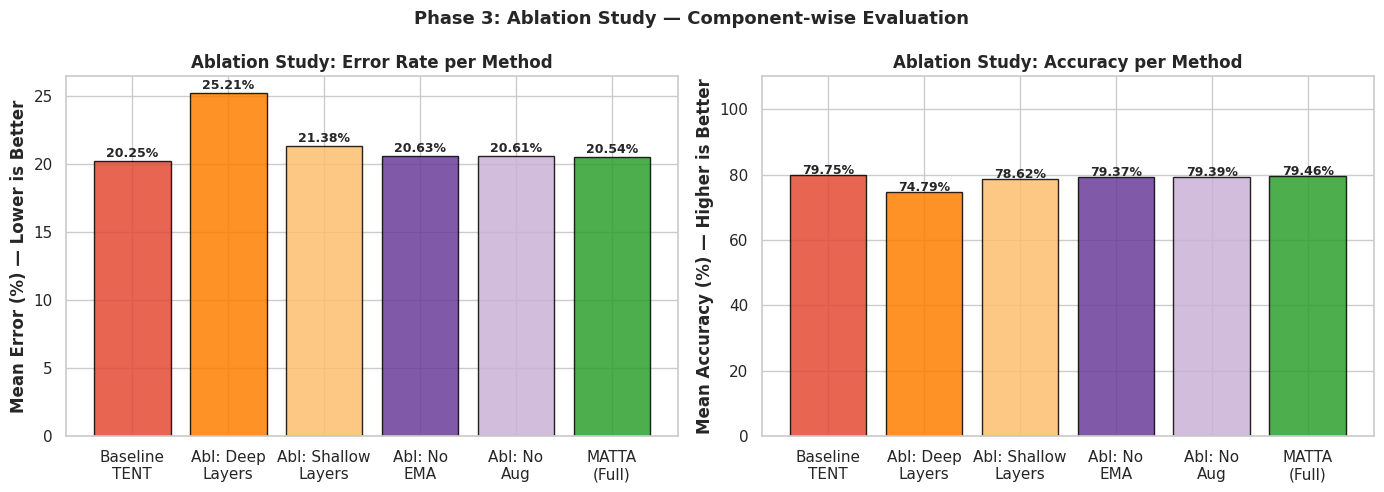

Saved: phase3_ablation.png


In [20]:
# Summary bar: mean accuracy per method
labels = ['Baseline\nTENT', 'Abl: Deep\nLayers', 'Abl: Shallow\nLayers', 'Abl: No\nEMA', 'Abl: No\nAug', 'MATTA\n(Full)']
errs   = [df_p3[c].mean() for c in df_p3.columns[1:]]
accs   = [100-e for e in errs]
colors = ['#e34a33','#ff7f00','#fdbf6f','#6a3d9a','#cab2d6','#2ca02c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(labels, errs, color=colors, edgecolor='black', alpha=0.85)
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{bar.get_height():.2f}%',
                 ha='center', fontweight='bold', fontsize=9)
axes[0].set_ylabel('Mean Error (%) — Lower is Better', fontweight='bold')
axes[0].set_title('Ablation Study: Error Rate per Method', fontweight='bold')

bars = axes[1].bar(labels, accs, color=colors, edgecolor='black', alpha=0.85)
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{bar.get_height():.2f}%',
                 ha='center', fontweight='bold', fontsize=9)
axes[1].set_ylabel('Mean Accuracy (%) — Higher is Better', fontweight='bold')
axes[1].set_title('Ablation Study: Accuracy per Method', fontweight='bold')
axes[1].set_ylim(0, 110)

plt.suptitle('Phase 3: Ablation Study — Component-wise Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase3_ablation.png', dpi=150)
plt.show()
print('Saved: phase3_ablation.png')

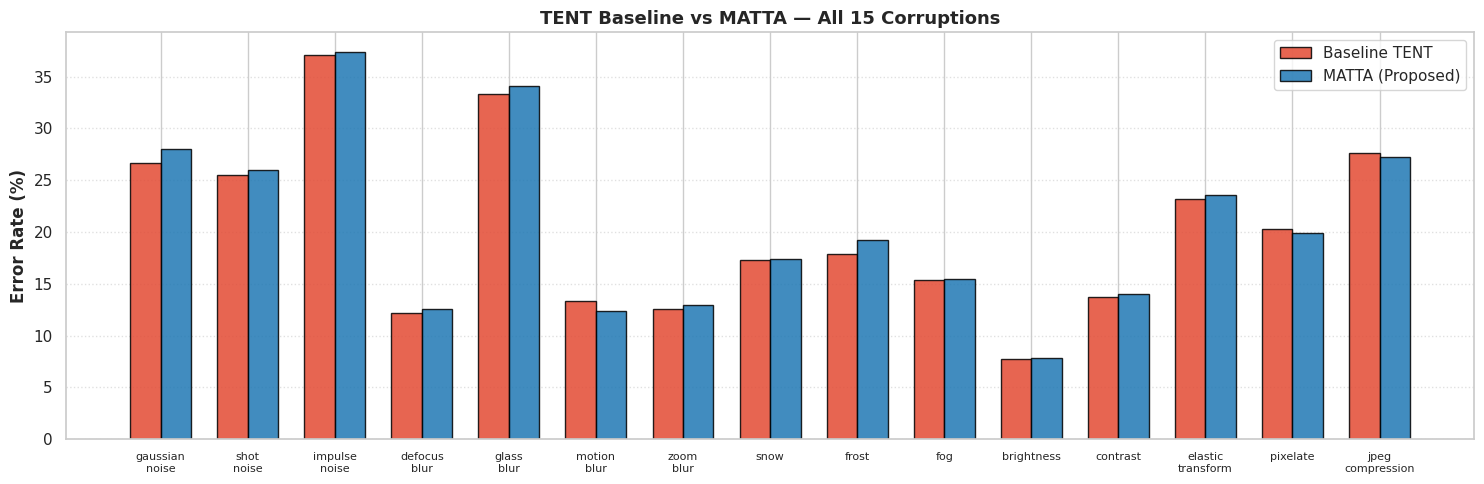

Saved: phase3_tent_vs_matta.png


In [21]:
# Domain-by-domain: TENT vs MATTA
x = np.arange(len(CORRUPTIONS))
w = 0.35
plt.figure(figsize=(15, 5))
plt.bar(x - w/2, df_p3['Baseline_TENT %'], w, label='Baseline TENT', color='#e34a33', edgecolor='black', alpha=0.85)
plt.bar(x + w/2, df_p3['MATTA_Full %'], w, label='MATTA (Proposed)', color='#1f78b4', edgecolor='black', alpha=0.85)
plt.xticks(x, [c.replace('_','\n') for c in CORRUPTIONS], fontsize=8)
plt.ylabel('Error Rate (%)', fontweight='bold')
plt.title('TENT Baseline vs MATTA — All 15 Corruptions', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('phase3_tent_vs_matta.png', dpi=150)
plt.show()
print('Saved: phase3_tent_vs_matta.png')

## 3.9 Hyperparameter Grid: EMA Alpha vs Num Views

Running MATTA hyperparameter grid (alpha × num_views)...
  α=0.9  V=1  Error: 19.93%
  α=0.9  V=2  Error: 19.70%
  α=0.9  V=4  Error: 19.83%
  α=0.99  V=1  Error: 19.77%
  α=0.99  V=2  Error: 19.70%
  α=0.99  V=4  Error: 19.93%
  α=0.999  V=1  Error: 19.77%
  α=0.999  V=2  Error: 19.67%
  α=0.999  V=4  Error: 19.97%


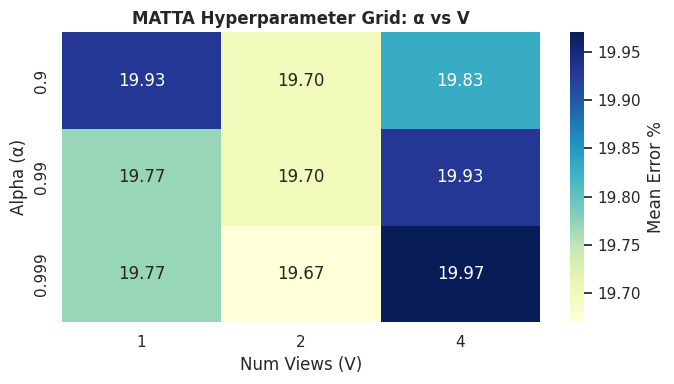

Saved: phase3_grid_search.png

Best: α=0.999, V=2, Error=19.67%


In [22]:
# Grid search on 3 corruptions for speed
GRID_CORRS = ['gaussian_noise', 'defocus_blur', 'frost']
ALPHAS = [0.9, 0.99, 0.999]
N_VIEWS = [1, 2, 4]

print('Running MATTA hyperparameter grid (alpha × num_views)...')
grid_records = []

for alpha in ALPHAS:
    for nv in N_VIEWS:
        errs = []
        for corr in GRID_CORRS:
            x, y = load_cifar10c(n_examples=N_EXAMPLES, corruptions=[corr],
                                 severity=SEVERITY, data_dir=DATA_DIR)
            loader = DataLoader(TensorDataset(x, y), batch_size=BATCH_SIZE, shuffle=False)
            matta = MATTAModel(copy.deepcopy(source_model), lr=best_lr, alpha=alpha, num_views=nv).to(DEVICE)
            correct = 0
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                with torch.enable_grad():
                    out = matta(xb)
                correct += (out.argmax(1) == yb).sum().item()
            errs.append(100*(1-correct/N_EXAMPLES))
        mean_err = np.mean(errs)
        grid_records.append({'Alpha (α)': alpha, 'Num Views (V)': nv, 'Mean Error %': round(mean_err, 2)})
        print(f'  α={alpha}  V={nv}  Error: {mean_err:.2f}%')

df_grid = pd.DataFrame(grid_records)
pivot = df_grid.pivot(index='Alpha (α)', columns='Num Views (V)', values='Mean Error %')

plt.figure(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Mean Error %'})
plt.title('MATTA Hyperparameter Grid: α vs V', fontweight='bold')
plt.tight_layout()
plt.savefig('phase3_grid_search.png', dpi=150)
plt.show()
print('Saved: phase3_grid_search.png')

best_row = df_grid.loc[df_grid['Mean Error %'].idxmin()]
best_alpha = best_row['Alpha (α)']
best_nviews = int(best_row['Num Views (V)'])
print(f'\nBest: α={best_alpha}, V={best_nviews}, Error={best_row["Mean Error %"]:.2f}%')